Data loaded successfully!

✓ Baseline scores extracted
{'BLEU-1': 0.7091, 'BLEU-2': 0.6724, 'BLEU-3': 0.6402, 'BLEU-4': 0.6142, 'METEOR': 0.4433, 'ROUGE-L': 0.6838, 'REG': 0.6763}

✓ Improvement data calculated:
          BLEU-1    BLEU-2    BLEU-3    BLEU-4    METEOR    ROUGE-L       REG
Model                                                                        
TITAN   4.273022  4.610351  4.701656  4.656464  5.256034  11.143609  9.788555
UNI2_4  4.385841  4.372397  4.264292  4.135461  4.556734   4.431120  3.252994
UNI1    1.635876  1.591315  1.452671  1.269945  1.601624   1.433168  0.768890

✓ Significance data extracted

✓ Annotations prepared

✓ Heatmap saved as PDF and PNG


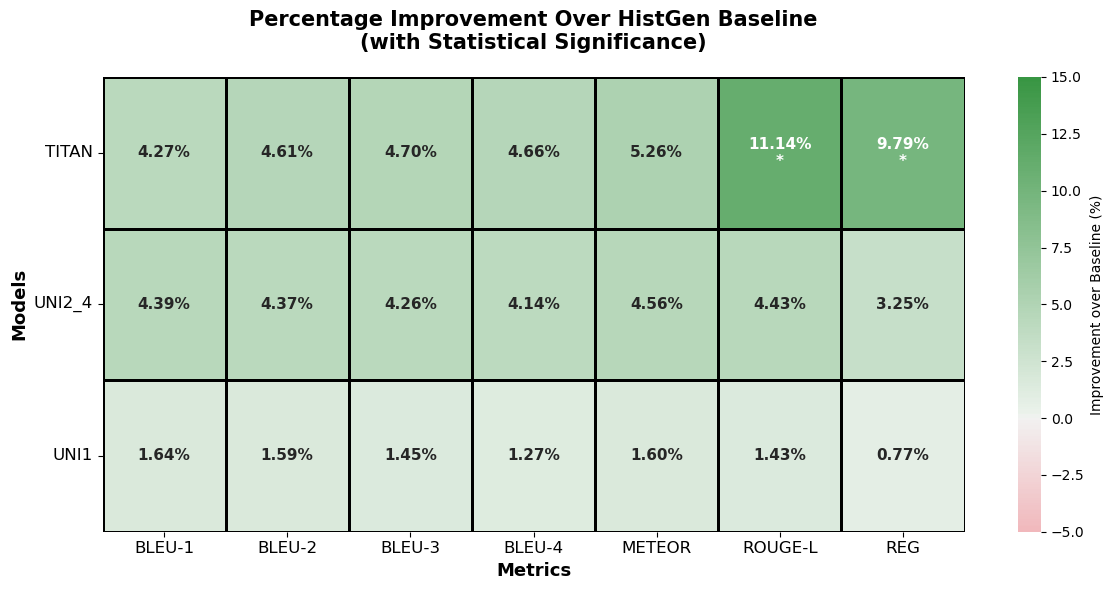


HEATMAP INTERPRETATION:
✓ Rows = Models (TITAN, UNI2_4, UNI1)
✓ Columns = Metrics
✓ Cell values = % improvement over HistGen baseline
✓ Color coding:
    - Green = positive improvement
    - Red = negative (worse than baseline)
    - White = no change
✓ Asterisks show statistical significance (*, **, ***)

Key insights:
  - Which model has most green cells? (most consistent improvement)
  - Which metrics show significant improvements?
  - Are there any red cells? (degradations)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define color palette
model_colors = {
    'HistGen': '#7f8c8d',
    'UNI': '#3498db',
    'UNI2': '#8e44ad',
    'TITAN': '#e74c3c'
}

# Function to parse mean ± std format
def parse_mean_std(value_str):
    parts = value_str.split('±')
    mean = float(parts[0].strip())
    std = float(parts[1].strip())
    return mean, std

# Read the CSV files
corpus_df = pd.read_csv('corpus_scores_summary_formatted.csv')
reg_df = pd.read_csv('reg_scores_summary_formatted.csv')
corpus_ttest_df = pd.read_csv('corpus_paired_ttest_with_bootstrap_detailed.csv')
reg_ttest_df = pd.read_csv('reg_statistical_analysis_with_bootstrap.csv')

print("Data loaded successfully!")

# Get models and metrics
models = corpus_df['Model'].tolist()
metrics = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4', 'METEOR', 'ROUGE-L', 'REG']

# Extract baseline (HistGen) scores
baseline_scores = {}
for metric in metrics[:-1]:
    value_str = corpus_df.loc[corpus_df['Model'] == 'HistGen', metric].values[0]
    mean, _ = parse_mean_std(value_str)
    baseline_scores[metric] = mean

# Add REG baseline
reg_value_str = reg_df.loc[reg_df['Model'] == 'HistGen', 'REG'].values[0]
mean, _ = parse_mean_std(reg_value_str)
baseline_scores['REG'] = mean

print("\n✓ Baseline scores extracted")
print(baseline_scores)

# Calculate % improvements for each model
improvement_data = []

for model in models:
    if model == 'HistGen':
        continue  # Skip baseline itself

    row_data = {'Model': model}

    # Corpus metrics
    for metric in metrics[:-1]:
        value_str = corpus_df.loc[corpus_df['Model'] == model, metric].values[0]
        mean, _ = parse_mean_std(value_str)

        # Calculate % improvement
        baseline = baseline_scores[metric]
        improvement_pct = ((mean - baseline) / baseline) * 100
        row_data[metric] = improvement_pct

    # REG metric
    reg_value_str = reg_df.loc[reg_df['Model'] == model, 'REG'].values[0]
    mean, _ = parse_mean_std(reg_value_str)
    baseline = baseline_scores['REG']
    improvement_pct = ((mean - baseline) / baseline) * 100
    row_data['REG'] = improvement_pct

    improvement_data.append(row_data)

# Create DataFrame
improvement_df = pd.DataFrame(improvement_data)
improvement_df = improvement_df.set_index('Model')

# Reorder to match your preferred order
improvement_df = improvement_df.reindex(['TITAN', 'UNI2', 'UNI'])
improvement_df = improvement_df[metrics]  # Ensure column order

print("\n✓ Improvement data calculated:")
print(improvement_df)

# Extract significance data
significance_dict = {}

# Corpus metrics
for _, row in corpus_ttest_df.iterrows():
    metric = row['Metric'].replace('test_', '').replace('_', '-')
    model = row['Model']
    significance = row['Significance']
    significance_dict[(model, metric)] = significance

# REG metric
for _, row in reg_ttest_df.iterrows():
    comparison = row['Comparison']
    model = comparison.split(' vs ')[0]
    significance = row['Significance']
    significance_dict[(model, 'REG')] = significance

print("\n✓ Significance data extracted")

# Create annotation matrix with significance markers
annotations = []
for model in improvement_df.index:
    row_annotations = []
    for metric in improvement_df.columns:
        value = improvement_df.loc[model, metric]
        sig = significance_dict.get((model, metric), 'ns')

        # Format: percentage with significance marker
        if sig != 'ns':
            annotation = f"{value:.2f}%\n{sig}"
        else:
            annotation = f"{value:.2f}%"

        row_annotations.append(annotation)
    annotations.append(row_annotations)

print("\n✓ Annotations prepared")

# ============================================================
# Create Heatmap
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

# Create custom colormap: red (negative) -> white (zero) -> green (positive)
cmap = sns.diverging_palette(10, 130, s=80, l=55, as_cmap=True)

# Create heatmap
sns.heatmap(improvement_df, annot=annotations, fmt='', cmap=cmap, center=0,
            cbar_kws={'label': 'Improvement over Baseline (%)'},
            linewidths=2, linecolor='black',
            annot_kws={'fontsize': 11, 'fontweight': 'bold'},
            vmin=-5, vmax=15,  # Adjust based on your data range
            ax=ax)

# Styling
ax.set_xlabel('Metrics', fontsize=13, fontweight='bold')
ax.set_ylabel('Models', fontsize=13, fontweight='bold')
ax.set_title('Percentage Improvement Over HistGen Baseline\n(with Statistical Significance)', 
             fontsize=15, fontweight='bold', pad=20)

# Rotate labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)

plt.tight_layout()

# Save figure
plt.savefig('heatmap_improvement_over_baseline.pdf', dpi=300, bbox_inches='tight')
plt.savefig('heatmap_improvement_over_baseline.png', dpi=300, bbox_inches='tight')
print("\n✓ Heatmap saved as PDF and PNG")

plt.show()

print("\n" + "="*70)
print("HEATMAP INTERPRETATION:")
print("="*70)
print("✓ Rows = Models (TITAN, UNI2_4, UNI1)")
print("✓ Columns = Metrics")
print("✓ Cell values = % improvement over HistGen baseline")
print("✓ Color coding:")
print("    - Green = positive improvement")
print("    - Red = negative (worse than baseline)")
print("    - White = no change")
print("✓ Asterisks show statistical significance (*, **, ***)")
print("="*70)
print("\nKey insights:")
print("  - Which model has most green cells? (most consistent improvement)")
print("  - Which metrics show significant improvements?")
print("  - Are there any red cells? (degradations)")
print("="*70)